# End-to-End Churn Prediction Model
### Online Tea Retail Store — Customer Retention Analysis

This notebook covers the full ML pipeline:
1. Data loading & conversion
2. Exploratory Data Analysis (EDA)
3. Data cleaning
4. Feature engineering
5. Model training (XGBoost)
6. Evaluation (AUC-ROC)
7. Model registration & API deployment
8. Endpoint testing

## 0. Install Dependencies

In [25]:
# Run this cell once to install required packages
import subprocess, sys
packages = ['xgboost', 'scikit-learn', 'pandas', 'numpy', 'matplotlib',
            'seaborn', 'openpyxl', 'joblib', 'fastapi', 'uvicorn', 'requests']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages installed!')

All packages installed!


## 1. Data Loading & Conversion (XLSX → CSV)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the Excel file
df_raw = pd.read_excel('storedata_total.xlsx')

# Convert and save as CSV (as required by the project)
df_raw.to_csv('storedata_total.csv', index=False)
print('Converted to CSV successfully!')

# Load from CSV going forward
df = pd.read_csv('storedata_total.csv', parse_dates=['created', 'firstorder', 'lastorder'])

print(f'\nDataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Converted to CSV successfully!

Dataset shape: (30801, 15)
Columns: ['custid', 'retained', 'created', 'firstorder', 'lastorder', 'esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq', 'paperless', 'refill', 'doorstep', 'favday', 'city']


,custid,retained,created,firstorder,lastorder,esent,eopenrate,eclickrate,avgorder,ordfreq,paperless,refill,doorstep,favday,city
0,6H6T6N,0,2012-09-28,2013-08-11 00:00:00,2013-08-11 00:00:00,29,100.000000,3.448276,14.52,0.000000,0,0,0,Monday,DEL
1,APCENR,1,2010-12-19,2011-04-01 00:00:00,2014-01-19 00:00:00,95,92.631579,10.526316,83.69,0.181641,1,1,1,Friday,DEL
2,7UP6MS,0,2010-10-03,2010-12-01 00:00:00,2011-07-06 00:00:00,0,0.000000,0.000000,33.58,0.059908,0,0,0,Wednesday,DEL
3,7ZEW8G,0,2010-10-22,2011-03-28 00:00:00,2011-03-28 00:00:00,0,0.000000,0.000000,54.96,0.000000,0,0,0,Thursday,BOM
4,8V726M,1,2010-11-27,2010-11-29 00:00:00,2013-01-28 00:00:00,30,90.000000,13.333333,111.91,0.008850,0,0,0,Monday,BOM


## 2. Exploratory Data Analysis (EDA)

In [27]:
# Dataset overview
print('=== Dataset Info ===')
df.info()
print('\n=== Basic Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 30801 entries, 0 to 30800
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   custid      30781 non-null  str           
 1   retained    30801 non-null  int64         
 2   created     30781 non-null  datetime64[us]
 3   firstorder  30781 non-null  str           
 4   lastorder   30781 non-null  str           
 5   esent       30801 non-null  int64         
 6   eopenrate   30801 non-null  float64       
 7   eclickrate  30801 non-null  float64       
 8   avgorder    30801 non-null  float64       
 9   ordfreq     30801 non-null  float64       
 10  paperless   30801 non-null  int64         
 11  refill      30801 non-null  int64         
 12  doorstep    30801 non-null  int64         
 13  favday      30801 non-null  str           
 14  city        30801 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(5), str(5)
memory us

,retained,created,esent,eopenrate,eclickrate,avgorder,ordfreq,paperless,refill,doorstep
count,30801.000000,30781,30801.000000,30801.000000,30801.000000,30801.000000,30801.000000,30801.000000,30801.000000,30801.000000
mean,0.794520,2013-10-12 23:14:03.598323,28.138405,25.554838,5.671139,61.873944,0.037729,0.649037,0.095094,0.038895
min,0.000000,2008-06-17 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2012-09-04 00:00:00,16.000000,2.040816,0.000000,40.020000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,2013-09-22 00:00:00,32.000000,13.207547,0.000000,50.970000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,2013-12-16 00:00:00,42.000000,40.000000,7.142857,74.280000,0.040816,1.000000,0.000000,0.000000
max,1.000000,2018-01-17 00:00:00,291.000000,100.000000,100.000000,2600.140000,3.250000,1.000000,1.000000,1.000000
std,0.404059,NaN,16.751380,29.557106,10.561704,41.007588,0.103932,0.477279,0.293350,0.193347


In [28]:
# Missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
            Missing Count  Missing %
custid                 20       0.06
created                20       0.06
firstorder             20       0.06
lastorder              20       0.06


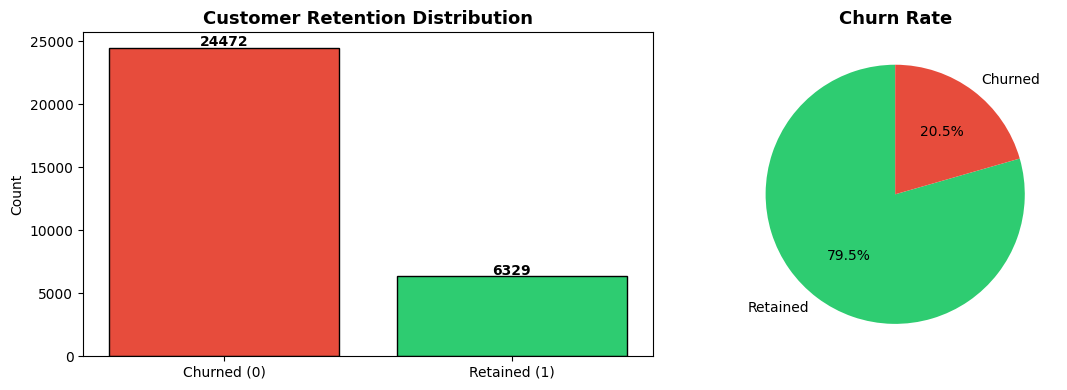

Churn rate: 20.5%
Retention rate: 79.5%


In [29]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['retained'].value_counts()
axes[0].bar(['Churned (0)', 'Retained (1)'], churn_counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Customer Retention Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Churn rate: {(churn_counts[0]/len(df)*100):.1f}%')
print(f'Retention rate: {(churn_counts[1]/len(df)*100):.1f}%')

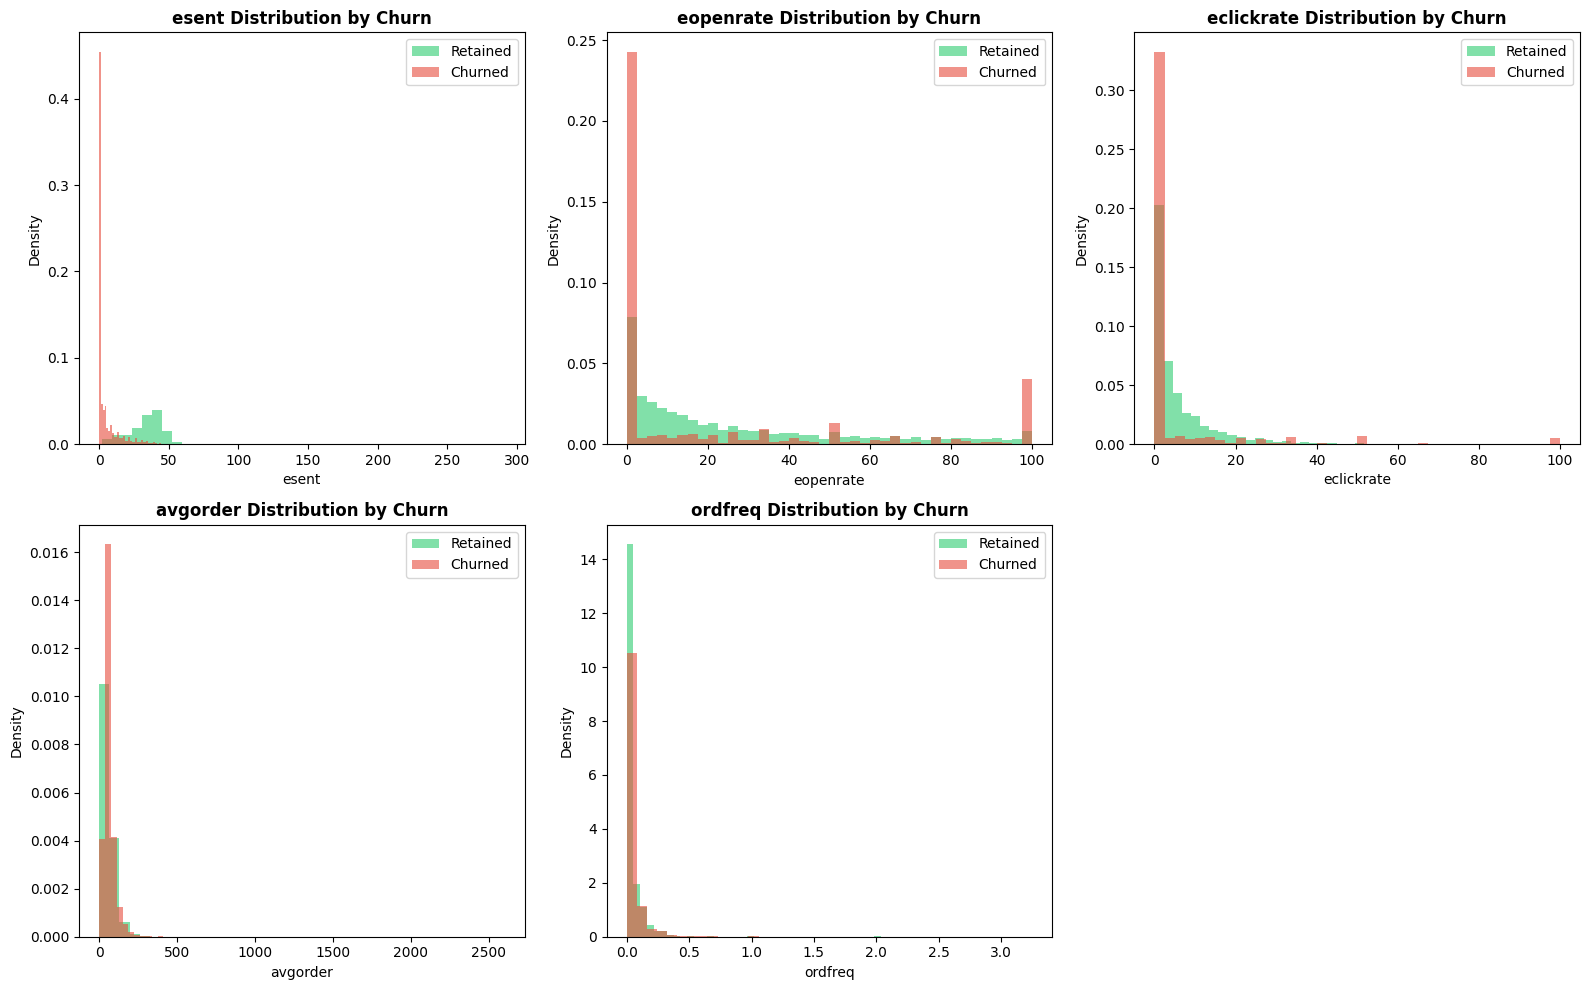

In [30]:
# Numerical features vs churn
num_cols = ['esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    retained = df[df['retained'] == 1][col].dropna()
    churned  = df[df['retained'] == 0][col].dropna()
    axes[i].hist(retained, bins=40, alpha=0.6, color='#2ecc71', label='Retained', density=True)
    axes[i].hist(churned,  bins=40, alpha=0.6, color='#e74c3c', label='Churned',  density=True)
    axes[i].set_title(f'{col} Distribution by Churn', fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

axes[-1].axis('off')
plt.tight_layout()
plt.savefig('02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

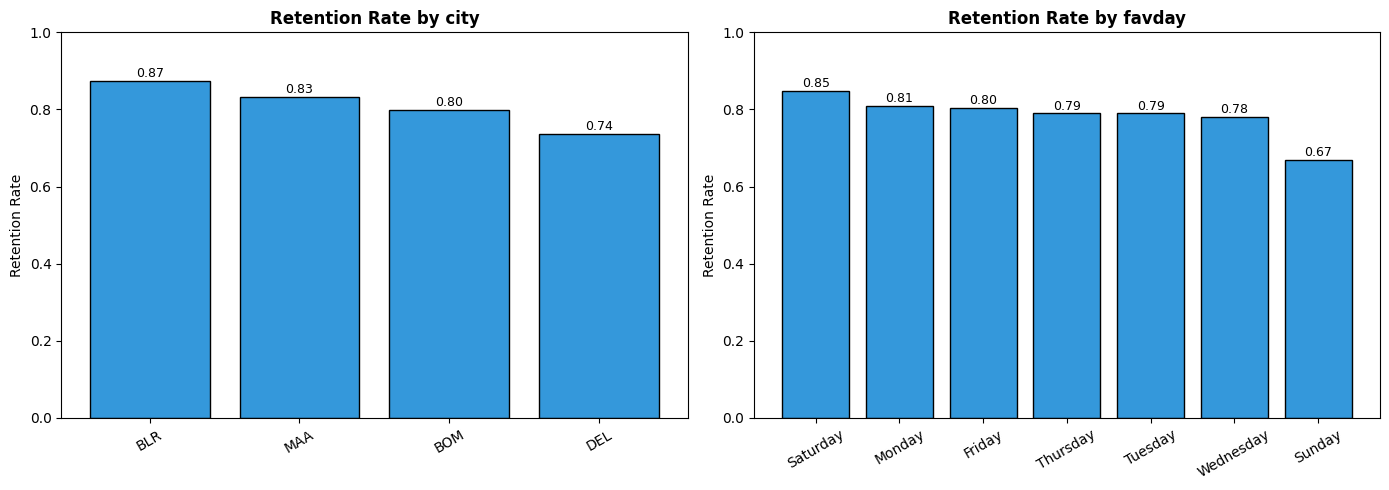

In [31]:
# Categorical features vs churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['city', 'favday']):
    churn_by_cat = df.groupby(col)['retained'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_by_cat.index, churn_by_cat.values, color='#3498db', edgecolor='black')
    ax.set_title(f'Retention Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Retention Rate')
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, churn_by_cat.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('03_categorical_retention.png', dpi=150, bbox_inches='tight')
plt.show()

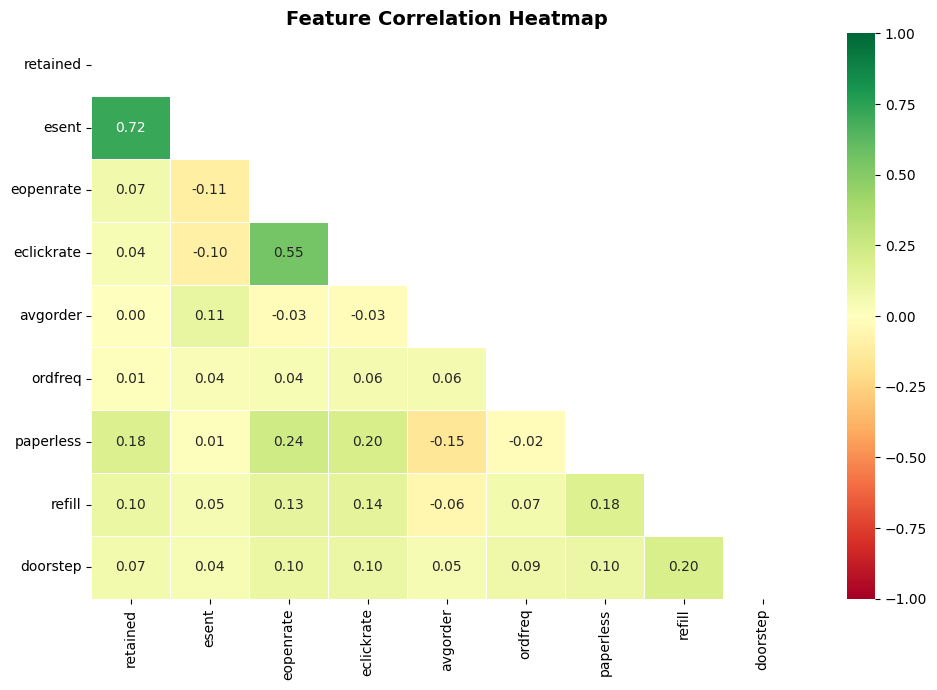

In [32]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr_cols = ['retained', 'esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq', 'paperless', 'refill', 'doorstep']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask,
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Cleaning

In [33]:
# Work on a clean copy
df_clean = df.copy()

# Drop rows with missing values (only 20 rows, <0.1% of data)
df_clean.dropna(subset=['custid', 'created', 'firstorder', 'lastorder'], inplace=True)
print(f'Rows after dropping nulls: {len(df_clean)} (removed {len(df) - len(df_clean)})')

# Ensure date columns are datetime
for col in ['created', 'firstorder', 'lastorder']:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Drop any rows where date parsing failed
df_clean.dropna(subset=['created', 'firstorder', 'lastorder'], inplace=True)
print(f'Rows after date cleaning: {len(df_clean)}')

# Remove duplicates
dupes_before = len(df_clean)
df_clean.drop_duplicates(subset=['custid'], inplace=True)
print(f'Duplicate customer IDs removed: {dupes_before - len(df_clean)}')

# Clip extreme outliers in numerical columns using IQR
for col in ['esent', 'avgorder', 'ordfreq']:
    Q1 = df_clean[col].quantile(0.01)
    Q3 = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(Q1, Q3)

# Validate binary columns
for col in ['paperless', 'refill', 'doorstep']:
    assert df_clean[col].isin([0, 1]).all(), f'{col} has unexpected values'

print(f'\nClean dataset shape: {df_clean.shape}')
print('Missing values remaining:', df_clean.isnull().sum().sum())

Rows after dropping nulls: 30781 (removed 20)
Rows after date cleaning: 30747
Duplicate customer IDs removed: 6

Clean dataset shape: (30741, 15)
Missing values remaining: 0


## 4. Feature Engineering

In [75]:
df_feat = df_clean.copy()

ref_date = df_feat['lastorder'].max()

# --- Engineered features ---

# Active period: span between first and last order
df_feat['active_period_days'] = (df_feat['lastorder'] - df_feat['firstorder']).dt.days.clip(lower=0)

# Customer age: days from account creation to last order
df_feat['customer_age_days'] = (df_feat['lastorder'] - df_feat['created']).dt.days.clip(lower=0)

# Recency ratio: how recently they ordered relative to their total tenure
# Close to 0 = ordered recently relative to account life (good)
# Close to 1 = last order was very early in their account life (churn signal)
df_feat['recency_ratio'] = np.where(
    df_feat['customer_age_days'] > 0,
    df_feat['active_period_days'] / df_feat['customer_age_days'],
    0  # if customer_age_days is 0, ratio is 0 (they just signed up)
)

# Email send rate: normalises esent by how long they've been active
# Removes survivorship bias (long-tenure customers naturally receive more emails)
# df_feat['esent_rate'] = np.where(
#     df_feat['active_period_days'] > 0,
#     df_feat['esent'] / df_feat['active_period_days'],
#     0
# )
# NOTE — esent dominance & data limitation:
# esent (emails sent) accounts for ~75% of feature importance. We attempted to normalise it
# (esent / active_period_days) to remove tenure bias — retained customers naturally receive
# more emails simply by being around longer. However, normalising it degraded model performance
# significantly (AUC: 0.978 → 0.910) because the dataset lacks sufficient alternative signals
# to compensate. The core issue is a data limitation — without richer behavioural features
# (purchase cadence, support interactions, browsing behaviour etc.), the model has little
# else to learn from. esent remains because it works, but its dominance is a known caveat. 
# It is a strong signal, other strong signals would improve the model further.

# Email engagement: replaces eopenrate + eclickrate (corr=0.72, redundant individually)
df_feat['email_engagement_score'] = (df_feat['eopenrate'] + df_feat['eclickrate']) / 2

# Revenue proxy: replaces avgorder + ordfreq individually
df_feat['total_revenue_proxy'] = df_feat['avgorder'] * df_feat['ordfreq']

# Weekend preference flag
df_feat['favday_is_weekend'] = df_feat['favday'].isin(['Saturday', 'Sunday']).astype(int)

# City one-hot encoding
city_dummies = pd.get_dummies(df_feat['city'], prefix='city', drop_first=True)
print('City dummies created:', city_dummies.columns.tolist())  # add this
df_feat = pd.concat([df_feat, city_dummies], axis=1)

# --- Final feature list ---
# Note: eopenrate, eclickrate dropped (replaced by email_engagement_score)
#       avgorder, ordfreq dropped (replaced by total_revenue_proxy)
#       services_adopted dropped (keeping individual flags for per-service signal)
city_cols = city_dummies.columns.tolist()
feature_cols = [
    'esent',                 # raw volume signal
    'paperless', 'refill', 'doorstep',
    'email_engagement_score',
    'total_revenue_proxy',
    'active_period_days',
    'recency_ratio',         # replaces days_since_last_order + customer_age_days
    'favday_is_weekend'
] + city_cols

print(f'Final feature count: {len(feature_cols)}')
print('Features:', feature_cols)

City dummies created: ['city_BOM', 'city_DEL', 'city_MAA']
Final feature count: 12
Features: ['esent', 'paperless', 'refill', 'doorstep', 'email_engagement_score', 'total_revenue_proxy', 'active_period_days', 'recency_ratio', 'favday_is_weekend', 'city_BOM', 'city_DEL', 'city_MAA']


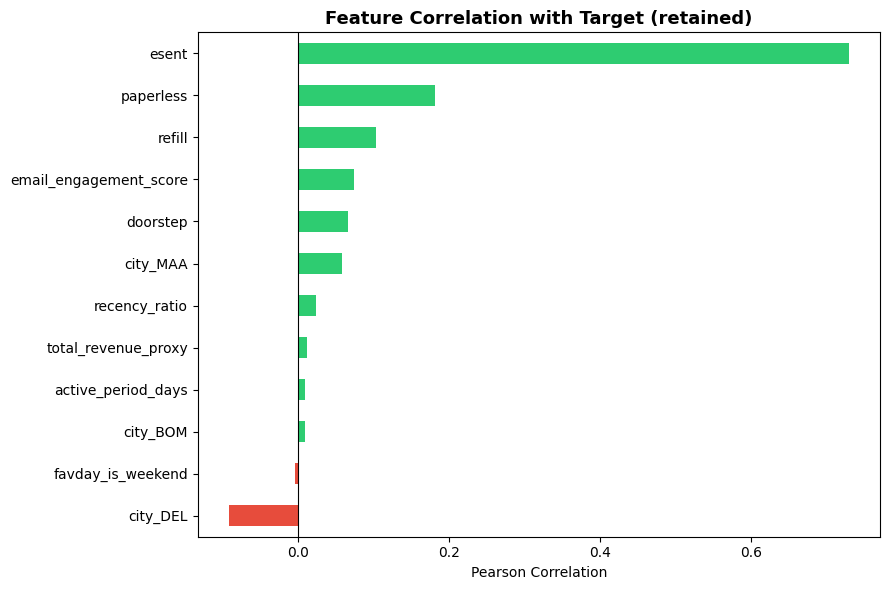

In [76]:
corr_with_target = df_feat[feature_cols + ['retained']].corr()['retained'].drop('retained').sort_values()

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Target (retained)', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('05_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Training

In [77]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import joblib

# Prepare features and target
X = df_feat[feature_cols].copy()
y = df_feat['retained'].copy()

# Handle any remaining NaN/Inf values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

# Train / validation / test split (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Training set:   {X_train.shape[0]:,} rows')
print(f'Validation set: {X_val.shape[0]:,} rows')
print(f'Test set:       {X_test.shape[0]:,} rows')

# Class weight for imbalance
# XGBoost's positive class is label 1 = Retained (majority)
# We want to upweight the minority class (Churned = label 0)
# So we downweight the positive class by saying neg / pos instead of pos / neg (standard majority / minority)
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f'\nClass imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}')

Training set:   21,518 rows
Validation set: 4,611 rows
Test set:       4,612 rows

Class imbalance ratio (scale_pos_weight): 0.26


In [78]:
# Train XGBoost model
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f'\nBest iteration: {model.best_iteration}')

[0]	validation_0-auc:0.96789
[23]	validation_0-auc:0.97061

Best iteration: 3


In [79]:
# Cross-validation AUC on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_model = XGBClassifier(
    n_estimators=model.best_iteration,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)
cv_scores = cross_val_score(cv_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'Cross-Validation AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation AUC: 0.9736 ± 0.0024


## 6. Model Evaluation (AUC-ROC)

In [80]:
# Predictions on test set
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# AUC-ROC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f'=== TEST SET EVALUATION ===')
print(f'AUC-ROC Score: {auc_score:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Churned', 'Retained']))

=== TEST SET EVALUATION ===
AUC-ROC Score: 0.9780

Classification Report:
              precision    recall  f1-score   support

     Churned       0.83      0.91      0.87       947
    Retained       0.98      0.95      0.96      3665

    accuracy                           0.94      4612
   macro avg       0.90      0.93      0.92      4612
weighted avg       0.95      0.94      0.94      4612



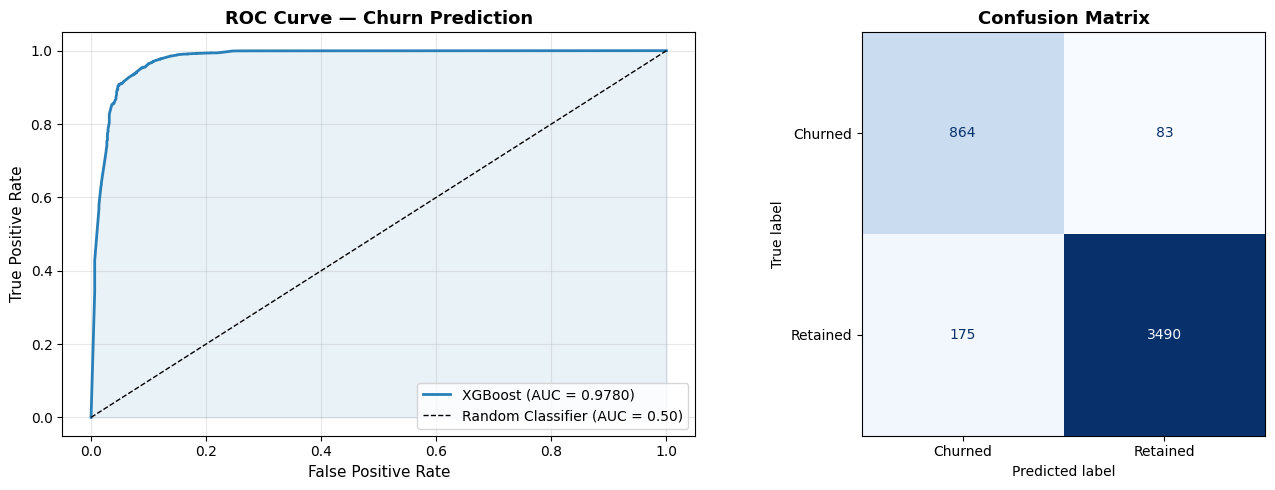

In [81]:
# ROC Curve plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#2980b9', lw=2, label=f'XGBoost (AUC = {auc_score:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve — Churn Prediction', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Churned', 'Retained'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('06_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

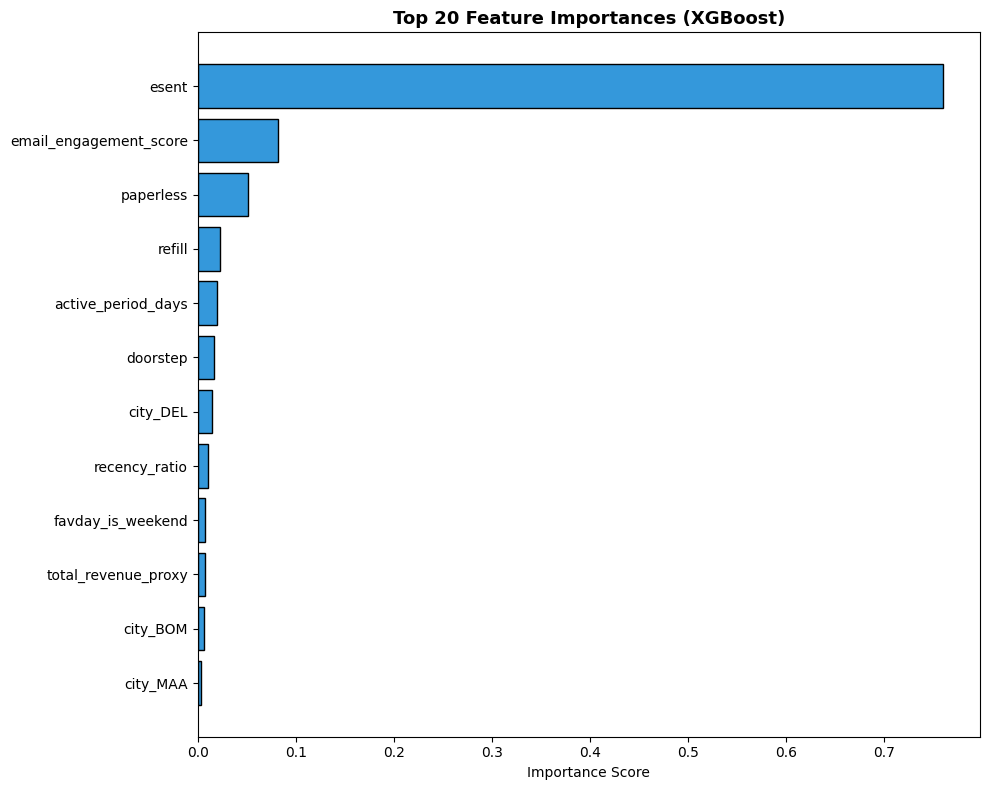

In [82]:
# Feature importance plot
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='#3498db', edgecolor='black')
plt.title('Top 20 Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Registration & Saving

In [83]:
import json
from datetime import datetime

# Save the trained model
joblib.dump(model, 'churn_model.pkl')
print('Model saved as churn_model.pkl')

# Save feature list (needed for inference)
with open('feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)
print('Feature columns saved as feature_columns.json')

# Model registry card (metadata)
model_card = {
    'model_name': 'churn_prediction_xgboost',
    'version': '1.0.0',
    'registered_at': datetime.now().isoformat(),
    'algorithm': 'XGBoostClassifier',
    'target': 'retained',
    'task': 'binary_classification',
    'n_features': len(feature_cols),
    'training_samples': len(X_train),
    'metrics': {
        'test_auc_roc': round(float(auc_score), 4),
        'cv_auc_mean': round(float(cv_scores.mean()), 4),
        'cv_auc_std': round(float(cv_scores.std()), 4)
    },
    'hyperparameters': {
        'n_estimators': int(model.best_iteration),
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8
    },
    'features': feature_cols
}

with open('model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print('\nModel Card (Registry Entry):')
print(json.dumps(model_card, indent=2))

Model saved as churn_model.pkl
Feature columns saved as feature_columns.json

Model Card (Registry Entry):
{
  "model_name": "churn_prediction_xgboost",
  "version": "1.0.0",
  "registered_at": "2026-03-01T19:43:21.508636",
  "algorithm": "XGBoostClassifier",
  "target": "retained",
  "task": "binary_classification",
  "n_features": 12,
  "training_samples": 21518,
  "metrics": {
    "test_auc_roc": 0.978,
    "cv_auc_mean": 0.9736,
    "cv_auc_std": 0.0024
  },
  "hyperparameters": {
    "n_estimators": 3,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8
  },
  "features": [
    "esent",
    "paperless",
    "refill",
    "doorstep",
    "email_engagement_score",
    "total_revenue_proxy",
    "active_period_days",
    "recency_ratio",
    "favday_is_weekend",
    "city_BOM",
    "city_DEL",
    "city_MAA"
  ]
}


## 8. API Deployment

We deploy the model as a REST API using FastAPI. The API replicates what a SageMaker endpoint would do — accept customer feature data and return a churn prediction with probability.

In [84]:
# Write the FastAPI app to a file
api_code = '''
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Optional
import numpy as np
import pandas as pd
import joblib
import json

app = FastAPI(
    title="Churn Prediction API",
    description="Predicts customer churn for an online tea retail store.",
    version="1.0.0"
)

# Load model and features at startup
model = joblib.load("churn_model.pkl")
with open("feature_columns.json") as f:
    FEATURE_COLS = json.load(f)

class CustomerFeatures(BaseModel):
    esent: float
    esent_rate: float
    paperless: int
    refill: int
    doorstep: int
    email_engagement_score: float
    total_revenue_proxy: float
    active_period_days: float
    recency_ratio: float
    favday_is_weekend: int
    city_BOM: Optional[int] = 0
    city_DEL: Optional[int] = 0
    city_MAA: Optional[int] = 0

class PredictionResponse(BaseModel):
    prediction: int
    prediction_label: str
    churn_probability: float
    retention_probability: float
    risk_level: str

@app.get("/")
def root():
    return {"message": "Churn Prediction API is running!", "docs": "/docs"}

@app.get("/health")
def health():
    return {"status": "healthy", "model": "churn_prediction_xgboost_v1.0"}

@app.post("/predict", response_model=PredictionResponse)
def predict(customer: CustomerFeatures):
    try:
        input_data = pd.DataFrame([customer.dict()])[FEATURE_COLS]
        input_data = input_data.fillna(0)
        
        proba = model.predict_proba(input_data)[0]
        churn_prob = float(proba[0])
        retain_prob = float(proba[1])
        prediction = int(model.predict(input_data)[0])
        
        if churn_prob >= 0.7:
            risk = "HIGH"
        elif churn_prob >= 0.4:
            risk = "MEDIUM"
        else:
            risk = "LOW"
        
        return PredictionResponse(
            prediction=prediction,
            prediction_label="Retained" if prediction == 1 else "Churned",
            churn_probability=round(churn_prob, 4),
            retention_probability=round(retain_prob, 4),
            risk_level=risk
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.post("/predict/batch")
def predict_batch(customers: list[CustomerFeatures]):
    results = []
    for customer in customers:
        input_data = pd.DataFrame([customer.dict()])[FEATURE_COLS]
        input_data = input_data.fillna(0)
        proba = model.predict_proba(input_data)[0]
        prediction = int(model.predict(input_data)[0])
        results.append({
            "prediction": prediction,
            "prediction_label": "Retained" if prediction == 1 else "Churned",
            "churn_probability": round(float(proba[0]), 4),
            "retention_probability": round(float(proba[1]), 4)
        })
    return {"predictions": results, "count": len(results)}

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)
'''

with open('app.py', 'w') as f:
    f.write(api_code)

print('FastAPI app written to app.py')
print('\nTo run locally, execute in terminal:')
print('  python app.py')
print('\nAPI will be available at:')
print('  http://localhost:8000         ← root')
print('  http://localhost:8000/health  ← health check')
print('  http://localhost:8000/predict ← prediction endpoint')
print('  http://localhost:8000/docs    ← interactive Swagger UI')

FastAPI app written to app.py

To run locally, execute in terminal:
  python app.py

API will be available at:
  http://localhost:8000         ← root
  http://localhost:8000/health  ← health check
  http://localhost:8000/predict ← prediction endpoint
  http://localhost:8000/docs    ← interactive Swagger UI


## 9. Testing the API Endpoint

In [85]:
import subprocess
import time
import requests
import threading

# Start the API server in the background
server = subprocess.Popen(['python', 'app.py'],
                          stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(3)  # Give server time to start
print('Server started (PID:', server.pid, ')')

Server started (PID: 91690 )


In [86]:
BASE_URL = 'http://localhost:8000'

# --- Test 1: Health check ---
print('=== Test 1: Health Check ===')
resp = requests.get(f'{BASE_URL}/health')
print(f'Status: {resp.status_code}')
print(f'Response: {resp.json()}')

=== Test 1: Health Check ===
Status: 200
Response: {'status': 'healthy', 'model': 'churn_prediction_xgboost_v1.0'}


In [87]:
# --- Test 2: Predict a likely-churned customer ---
print('=== Test 2: Likely Churned Customer ===')
churned_customer = {
    'esent': 3, 'esent_rate': 0.001,
    'paperless': 0, 'refill': 0, 'doorstep': 0,
    'email_engagement_score': 0.01,
    'total_revenue_proxy': 7.5,
    'active_period_days': 30,
    'recency_ratio': 0.95,
    'favday_is_weekend': 0,
    'city_BOM': 0, 'city_DEL': 1, 'city_MAA': 0
}
resp = requests.post(f'{BASE_URL}/predict', json=churned_customer)
print(f'Status: {resp.status_code}')
import json
print(json.dumps(resp.json(), indent=2))

=== Test 2: Likely Churned Customer ===
Status: 200
{
  "prediction": 0,
  "prediction_label": "Churned",
  "churn_probability": 0.5918,
  "retention_probability": 0.4082,
  "risk_level": "MEDIUM"
}


In [88]:
# --- Test 3: Predict a likely-retained customer ---
print('=== Test 3: Likely Retained Customer ===')
retained_customer = {
    'esent': 50, 'esent_rate': 0.056,
    'paperless': 1, 'refill': 1, 'doorstep': 1,
    'email_engagement_score': 0.7,
    'total_revenue_proxy': 2880.0,
    'active_period_days': 890,
    'recency_ratio': 0.1,
    'favday_is_weekend': 1,
    'city_BOM': 0, 'city_DEL': 0, 'city_MAA': 1
}
resp = requests.post(f'{BASE_URL}/predict', json=retained_customer)
print(f'Status: {resp.status_code}')
print(json.dumps(resp.json(), indent=2))

=== Test 3: Likely Retained Customer ===
Status: 200
{
  "prediction": 1,
  "prediction_label": "Retained",
  "churn_probability": 0.4267,
  "retention_probability": 0.5733,
  "risk_level": "MEDIUM"
}


In [89]:
# --- Test 4: Batch prediction ---
print('=== Test 4: Batch Prediction ===')
resp = requests.post(f'{BASE_URL}/predict/batch',
                     json=[churned_customer, retained_customer])
print(f'Status: {resp.status_code}')
print(json.dumps(resp.json(), indent=2))

=== Test 4: Batch Prediction ===
Status: 200
{
  "predictions": [
    {
      "prediction": 0,
      "prediction_label": "Churned",
      "churn_probability": 0.5918,
      "retention_probability": 0.4082
    },
    {
      "prediction": 1,
      "prediction_label": "Retained",
      "churn_probability": 0.4267,
      "retention_probability": 0.5733
    }
  ],
  "count": 2
}


In [90]:
# Shut down the server
server.terminate()
print('API server shut down.')

API server shut down.


## 10. Testing Deployment

In [92]:
import requests

# Health check
resp = requests.get('https://churn-prediction-capstone.onrender.com/health')
print(resp.json())

# Test prediction
churned_customer = {
    'esent': 3, 'esent_rate': 0.001,
    'paperless': 0, 'refill': 0, 'doorstep': 0,
    'email_engagement_score': 0.01,
    'total_revenue_proxy': 7.5,
    'active_period_days': 30,
    'recency_ratio': 0.95,
    'favday_is_weekend': 0,
    'city_BOM': 0, 'city_DEL': 1, 'city_MAA': 0
}
resp = requests.post('https://churn-prediction-capstone.onrender.com/predict', json=churned_customer)
print(resp.json())

{'status': 'healthy', 'model': 'churn_prediction_xgboost_v1.0'}
{'prediction': 0, 'prediction_label': 'Churned', 'churn_probability': 0.5918, 'retention_probability': 0.4082, 'risk_level': 'MEDIUM'}
